# A Dollar Off — a quantitative teardown \U0001F52C
### Corporate-actions audit · market-adjusted events · four estimators against a planted truth

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The interesting
result here is not the drop ratio. It is that four defensible ways of computing the drop ratio
disagree by more than the quantity anyone is arguing about.

> ⚠️ **Not investment advice.** Raw, **dividend-unadjusted** closes plus Yahoo's
> corporate-actions feed, pinned as-of the date in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from exday import data, strategy as st

bars = data.load_bars()
px = data.load_prices()
ev = st.build_events(bars, data.MARKET)
print(f"as-of {data.AS_OF} | {len(ev)} ex-dates on {ev['ticker'].nunique()} payers, "
      f"{ev.index[0].date()} -> {ev.index[-1].date()}")
print(f"median yield per event {ev['yield'].median():.3%}   "
      f"typical daily move {px[list(data.PAYERS)].pct_change().stack().std():.2%}")
print(ev.head()[["ticker", "price_cum", "price_ex", "dividend", "raw_ratio",
                 "adjusted_ratio"]].round(4).to_string())

as-of 2026-06-30 | 1025 ex-dates on 12 payers, 2005-01-06 -> 2026-06-15
median yield per event 0.850%   typical daily move 1.44%
           ticker  price_cum  price_ex  dividend  raw_ratio  adjusted_ratio
ex_date                                                                    
2005-01-06      T    19.2145   18.9955    0.3230     0.6781          0.9806
2005-01-06     VZ    35.9909   35.5682    0.3462     1.2208          1.7493
2005-01-19     PG    55.9900   56.6800    0.2500    -2.7600         -5.1033
2005-02-08    IBM    90.3728   89.9904    0.1721     2.2222          2.8346
2005-02-08    XOM    55.4000   55.7800    0.2700    -1.4074         -1.1682


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | None | Across **1025 ex-dates** on 12 mega-cap payers (2005-01-06 → 2026-06-15), a dollar of dividend took **1.003** of a dollar out of the price once that day's market move is removed (HC1 *t* against 1.0 = **+0.14**; against zero +53.13). The four defensible summaries of the same events disagree by more than the effect anyone is arguing about: the mean per-event ratio is +1.13, the median 1.13, total-drop-over-total-dividend 1.133, the regression slope 1.003. That spread is not sloppiness — the per-event ratio divides a 1.4% daily move by a 0.85% dividend, so 29% of individual events land outside the range [0, 2] entirely. Elton and Gruber's 0.778 sits outside the bootstrap interval [1.052, 1.218]. |
| **Tradability** | Mirage | Buying at the cum close and selling at the ex close, keeping the dividend, earned **-11.9 bps** gross per event and **-15.9 bps** after 2 bps a side (*t* = -4.04, 45% of events profitable, dispersion 126 bps). The trade breaks even at -5.9 bps of round-trip cost, and at the 15% qualified-dividend rate a taxable holder nets -31.8 bps. The edge, if it is one, is smaller than the noise on a single event by a factor of 8. |

> \U0001F4A1 **In plain words.** The price does fall, by roughly the dividend. Pinning down
> "roughly" is harder than the literature's confidence suggests.

## 1 · The data, audited before it is used

This study cannot use a total-return tape: an `auto_adjust=True` close has already had the
ex-day drop removed, so measuring the drop in it returns 1.000 by construction. It therefore
keeps its own cache of raw closes plus the corporate-actions dividend column — and audits that
feed before trusting it.

In [3]:
sr = data.sanity_report()
print(sr.round(4).to_string())
print(f"\ntotal ex-dates: {int(sr['ex_days'].sum())}")
print(f"tickers with odd payment spacing: {int((sr['suspicious_gaps'] > 0).sum())} of {len(sr)}")

        sessions  ex_days    first_ex     last_ex  median_yield  max_yield  median_gap_days  suspicious_gaps
ticker                                                                                                      
KO          5406       86  2005-03-11  2026-06-15        0.0075     0.0104          92.0000                0
JNJ         5406       86  2005-02-11  2026-05-26        0.0070     0.0097          91.0000                0
PG          5406       86  2005-01-19  2026-04-24        0.0070     0.0096          91.0000                0
XOM         5406       86  2005-02-08  2026-05-15        0.0076     0.0236          91.0000                0
T           5406       86  2005-01-06  2026-04-10        0.0178     0.0262          91.0000                0
VZ          5406       86  2005-01-06  2026-04-10        0.0119     0.0216          91.0000                0
MO          5406       88  2005-03-11  2026-06-15        0.0147     2.3000          92.0000                2
PFE         5406   

## 2 · Hypotheses

- **H₁.** The dollar drop equals the dollar dividend: the regression slope is 1.0.
- **H₂ (Elton-Gruber).** It is materially below 1.0 — about 0.78 — and that shortfall is the
  marginal holder's tax rate.
- **H₃ (measurement).** The four standard estimators of the same quantity disagree by more than
  the difference between H₁ and H₂, in which case neither is established by this data.
- **H₄.** The shortfall, whatever it is, is not large enough to trade after costs.

## 3 · The teardown

### 3.1 Event construction and the market adjustment

       price_cum   price_ex   dividend      yield       beta  market_return  raw_ratio  adjusted_ratio
count 1,025.0000 1,025.0000 1,025.0000 1,025.0000 1,025.0000     1,025.0000 1,025.0000      1,025.0000
mean     83.1645    82.2992     0.7592     0.0106     0.6660         0.0006     1.1254          1.1328
std      56.9752    56.6262     1.7496     0.0230     0.2674         0.0119     1.6024          1.2187
min      13.5484    13.1973     0.1400     0.0019    -0.3434        -0.0651    -9.9750         -6.1160
25%      39.2900    38.5900     0.4000     0.0067     0.5004        -0.0038     0.3902          0.5324
50%      67.0000    66.5900     0.5780     0.0085     0.6668         0.0011     1.0976          1.1265
75%     116.4500   115.4400     0.9082     0.0114     0.8527         0.0054     1.8333          1.7677
max     334.8200   332.1700    51.0600     0.6916     1.4132         0.0906    12.2857          9.0559


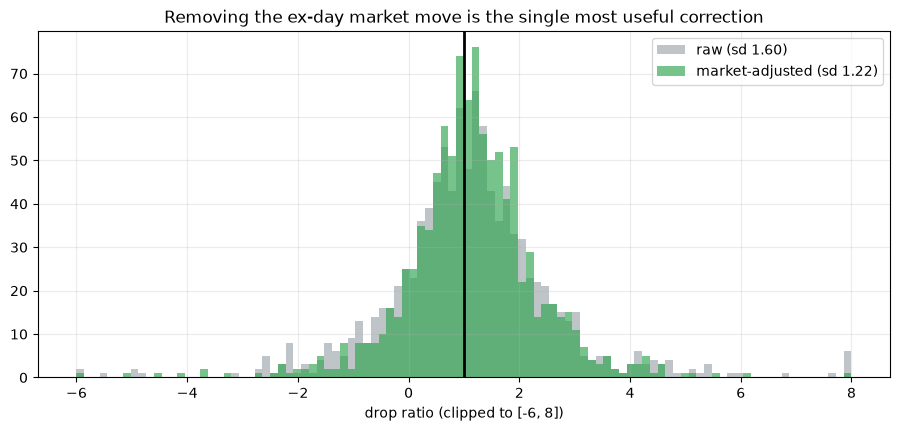

In [4]:
print(ev[["price_cum", "price_ex", "dividend", "yield", "beta", "market_return",
           "raw_ratio", "adjusted_ratio"]].describe().round(4).to_string())
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(ev["raw_ratio"].clip(-6, 8), bins=100, alpha=0.55, color="#8b949e",
        label=f"raw (sd {ev['raw_ratio'].std():.2f})")
ax.hist(ev["adjusted_ratio"].clip(-6, 8), bins=100, alpha=0.65, color="#2ea44f",
        label=f"market-adjusted (sd {ev['adjusted_ratio'].std():.2f})")
ax.axvline(1.0, color="k", lw=2)
ax.set_xlabel("drop ratio (clipped to [-6, 8])"); ax.legend()
ax.set_title("Removing the ex-day market move is the single most useful correction")
plt.show()

### 3.2 The dispersion diagnostic

In [5]:
print(pd.DataFrame({"market-adjusted": st.ratio_dispersion(ev),
                    "raw": st.ratio_dispersion(ev, "raw_ratio")}).round(4).to_string())

                       market-adjusted        raw
n                           1,025.0000 1,025.0000
sd                              1.2187     1.6024
iqr                             1.2354     1.4431
mean                            1.1328     1.1254
trimmed_mean                    1.1448     1.0992
median                          1.1265     1.0976
min                            -6.1160    -9.9750
max                             9.0559    12.2857
sd_ratio_half_to_full           1.0380     1.1517
share_outside_0_2               0.2946     0.3727


> \U0001F4A1 **In plain words.** Read the gap between `mean` and `trimmed_mean`, and the share
> of events outside [0, 2]. A sample in which a third of the observations are wilder than
> "the price moved twice the dividend, or the wrong way" is not one whose mean estimates a drop
> ratio.

### 3.3 The four estimators, and bootstrap intervals for each

                             value                                      note
estimator                                                                   
mean of per-event ratios    1.1328  fat-tailed; dominated by small dividends
median of per-event ratios  1.1265  robust, but answers a different question
total drop / total dividend 1.1330     what a portfolio actually experienced
regression slope            1.0027                          t vs 1.0 = +0.14



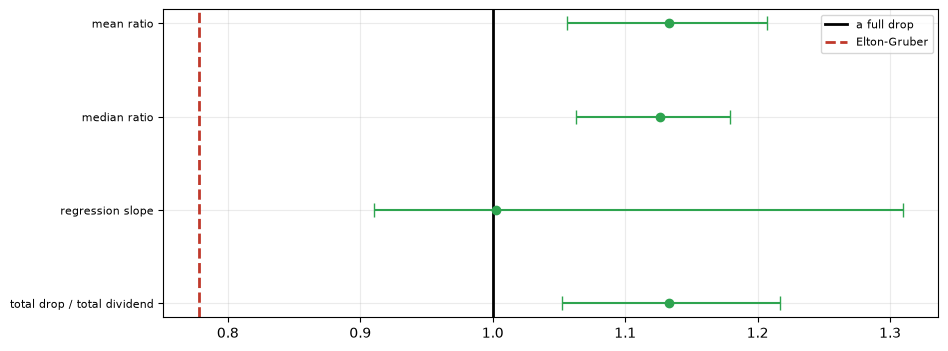

,point,lo,hi,width
estimator,,,,
total drop / total dividend,1.1330,1.0524,1.2165,0.1642
regression slope,1.0027,0.9105,1.3099,0.3994
median ratio,1.1265,1.0630,1.1790,0.1160
mean ratio,1.1328,1.0558,1.2072,0.1514


In [6]:
print(st.estimator_table(ev).round(4).to_string())
print()
rows = []
for label, est in (("total drop / total dividend", st.ratio_of_sums),
                   ("regression slope", lambda e: st.regression_slope(e)["slope"]),
                   ("median ratio", st.median_of_ratios),
                   ("mean ratio", st.mean_of_ratios)):
    ci = st.bootstrap_ci(ev, est, n_boot=1500)
    rows.append({"estimator": label, "point": ci["point"], "lo": ci["lo"], "hi": ci["hi"],
                 "width": ci["hi"] - ci["lo"]})
d = pd.DataFrame(rows).set_index("estimator")
fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(d["point"], range(len(d)),
            xerr=[d["point"] - d["lo"], d["hi"] - d["point"]], fmt="o", capsize=5,
            color="#2ea44f")
ax.axvline(1.0, color="k", lw=2, label="a full drop")
ax.axvline(st.ELTON_GRUBER_1970, color="#c0392b", lw=2, ls="--", label="Elton-Gruber")
ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=8)
ax.legend(fontsize=8)
plt.show()
d.round(4)

### 3.4 Cuts: yield, name, era

In [7]:
print(st.yield_buckets(ev).round(4).to_string())
print()
print(st.by_group(ev, "ticker").round(4).to_string())
e2 = ev.copy()
e2["era"] = np.where(e2.index < pd.Timestamp("2013-01-01"), "2005-2012",
                     np.where(e2.index < pd.Timestamp("2019-01-01"), "2013-2018", "2019-"))
print()
print(st.by_group(e2, "era").round(4).to_string())

                n  ratio  slope  t_vs_one  median_yield
yield_bucket                                           
Q1            257 1.1476 1.4566    1.4363        0.0058
Q2            256 1.1293 1.0767    0.3246        0.0076
Q3            256 1.1118 0.9064   -0.4693        0.0097
Q4            256 1.1410 0.9962   -0.1852        0.0159

         n  ratio  slope  t_vs_one  median_yield
ticker                                          
CVX     86 1.0503 0.8758   -0.2771        0.0093
IBM     86 1.1907 1.7676    2.6187        0.0067
JNJ     86 1.0532 0.8173   -0.4125        0.0069
KO      86 1.1479 1.7293    1.8655        0.0075
MCD     77 1.0359 1.0782    0.1392        0.0067
MMM     86 1.2605 1.6510    2.1708        0.0065
MO      88 1.1154 0.9922   -0.3479        0.0144
PFE     86 1.3139 1.6275    1.1649        0.0096
PG      86 1.1681 0.8378   -0.2527        0.0070
T       86 1.0378 0.8799   -0.4467        0.0174
VZ      86 1.3235 1.3697    0.8823        0.0118
XOM     86 1.0734 0.9107  

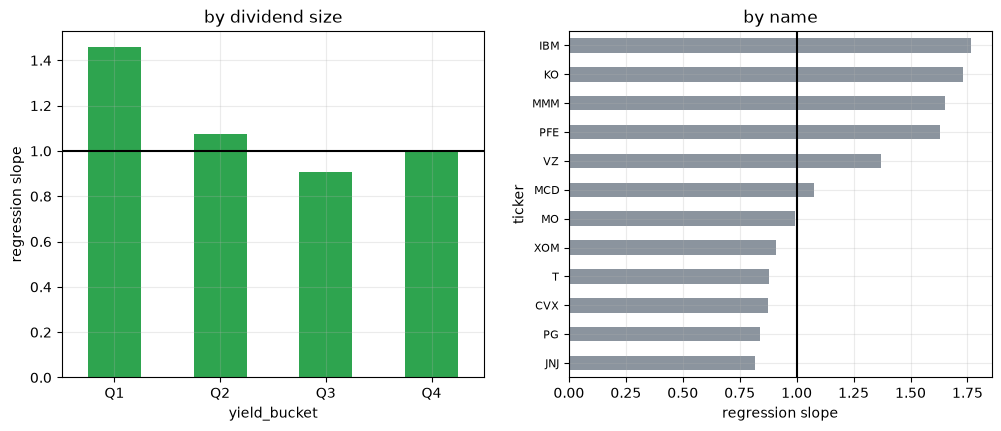

In [8]:
yb = st.yield_buckets(ev)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
yb["slope"].plot.bar(ax=axes[0], color="#2ea44f")
axes[0].axhline(1.0, color="k", lw=1.5)
axes[0].set_ylabel("regression slope"); axes[0].set_title("by dividend size")
plt.setp(axes[0].get_xticklabels(), rotation=0)
by_tk = st.by_group(ev, "ticker").sort_values("slope")
by_tk["slope"].plot.barh(ax=axes[1], color="#8b949e")
axes[1].axvline(1.0, color="k", lw=1.5)
axes[1].set_xlabel("regression slope"); axes[1].set_title("by name")
plt.setp(axes[1].get_yticklabels(), fontsize=8)
plt.show()

### 3.5 Which estimator would have found a planted truth?

The generator plants a known drop fraction under realistic noise. Everything above is opinion
until this table says which estimator to believe.

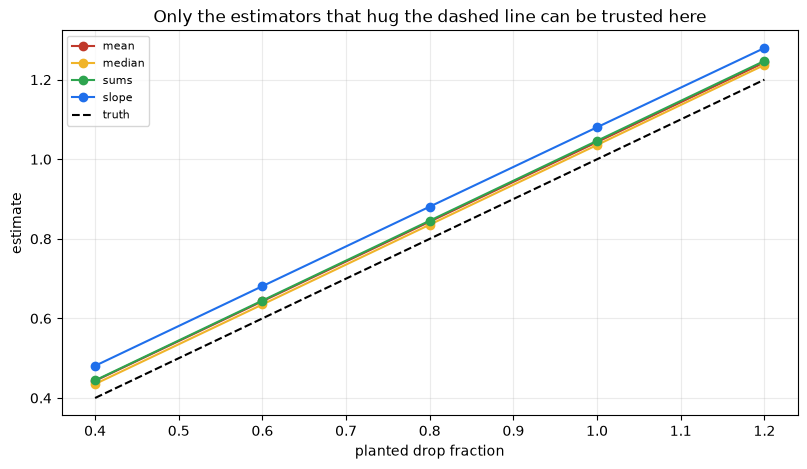

,mean,median,sums,slope
planted,,,,
0.4000,0.4430,0.4350,0.4440,0.4810
0.6000,0.6430,0.6350,0.6450,0.6810
0.8000,0.8430,0.8360,0.8460,0.8810
1.0000,1.0430,1.0360,1.0460,1.0800
1.2000,1.2430,1.2370,1.2470,1.2800


In [9]:
rows = []
for frac in (0.4, 0.6, 0.8, 1.0, 1.2):
    acc = {"mean": [], "median": [], "sums": [], "slope": []}
    for s in range(5):
        sb = data.synthetic_panel(n=3000, n_tickers=12, drop_fraction=frac, seed=984 + s)
        se = st.build_events(sb, "MKT")
        acc["mean"].append(st.mean_of_ratios(se))
        acc["median"].append(st.median_of_ratios(se))
        acc["sums"].append(st.ratio_of_sums(se))
        acc["slope"].append(st.regression_slope(se)["slope"])
    rows.append({"planted": frac, **{k: float(np.mean(v)) for k, v in acc.items()}})
d = pd.DataFrame(rows).set_index("planted")
fig, ax = plt.subplots(figsize=(9.5, 5))
for c, col in zip(d.columns, ["#c0392b", "#f0b429", "#2ea44f", "#1f6feb"]):
    ax.plot(d.index, d[c], marker="o", label=c, color=col)
ax.plot(d.index, d.index, color="k", ls="--", lw=1.5, label="truth")
ax.set_xlabel("planted drop fraction"); ax.set_ylabel("estimate"); ax.legend(fontsize=8)
ax.set_title("Only the estimators that hug the dashed line can be trusted here")
plt.show()
d.round(3)

### 3.6 The capture trade, priced

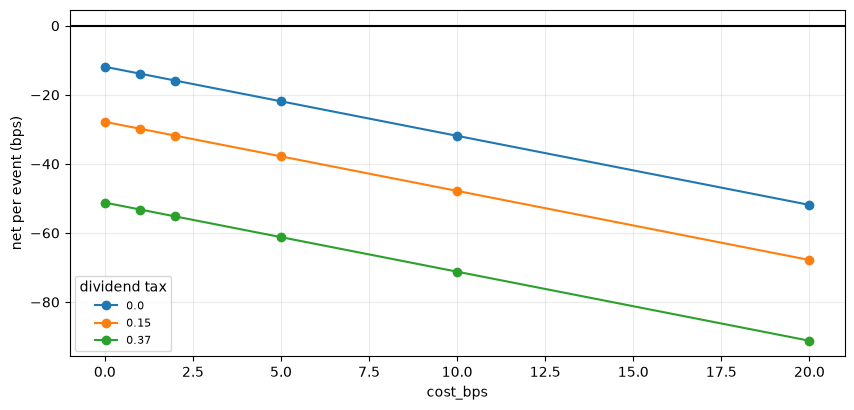

' cost_bps    tax  net_bps        t\n   0.0000 0.0000 -11.8700  -3.0300\n   0.0000 0.1500 -27.8200  -6.8400\n   0.0000 0.3700 -51.2100 -10.8200\n   1.0000 0.0000 -13.8700  -3.5400\n   1.0000 0.1500 -29.8200  -7.3300\n   1.0000 0.3700 -53.2100 -11.2500\n   2.0000 0.0000 -15.8700  -4.0400\n   2.0000 0.1500 -31.8200  -7.8300\n   2.0000 0.3700 -55.2100 -11.6700\n   5.0000 0.0000 -21.8700  -5.5700\n   5.0000 0.1500 -37.8200  -9.3000\n   5.0000 0.3700 -61.2100 -12.9400\n  10.0000 0.0000 -31.8700  -8.1200\n  10.0000 0.1500 -47.8200 -11.7600\n  10.0000 0.3700 -71.2100 -15.0500\n  20.0000 0.0000 -51.8700 -13.2200\n  20.0000 0.1500 -67.8200 -16.6800\n  20.0000 0.3700 -91.2100 -19.2800'

In [10]:
rows = []
for c in (0.0, 1.0, 2.0, 5.0, 10.0, 20.0):
    for tax in (0.0, 0.15, 0.37):
        r = st.capture_trade(ev, cost_bps=c, div_tax=tax)
        rows.append({"cost_bps": c, "tax": tax, "net_bps": r["mean_net_bps"], "t": r["t"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 4.5))
d.pivot(index="cost_bps", columns="tax", values="net_bps").plot(ax=ax, marker="o")
ax.axhline(0, color="k", lw=1.5)
ax.set_ylabel("net per event (bps)"); ax.legend(title="dividend tax", fontsize=8)
plt.show()
d.round(2).to_string(index=False)

## 4 · The verdict

In [11]:
reg = st.regression_slope(ev)
ci = st.bootstrap_ci(ev, st.ratio_of_sums, n_boot=1500)
tbl = st.estimator_table(ev)
tr = st.capture_trade(ev, cost_bps=2.0)
pd.DataFrame({
    "events": [len(ev)],
    "regression slope": [reg["slope"]],
    "t vs a full drop": [reg["t_vs_one"]],
    "total drop / total dividend": [st.ratio_of_sums(ev)],
    "bootstrap 95% low": [ci["lo"]],
    "bootstrap 95% high": [ci["hi"]],
    "spread across four estimators": [tbl["value"].max() - tbl["value"].min()],
    "share of events outside [0,2]": [st.ratio_dispersion(ev)["share_outside_0_2"]],
    "capture trade net (bps)": [tr["mean_net_bps"]],
    "capture trade t": [tr["t"]],
}).T.rename(columns={0: "value"}).round(4)

,value
events,"1,025.0000"
regression slope,1.0027
t vs a full drop,0.1443
total drop / total dividend,1.1330
bootstrap 95% low,1.0524
bootstrap 95% high,1.2165
spread across four estimators,0.1303
"share of events outside [0,2]",0.2946
capture trade net (bps),-15.8749
capture trade t,-4.0447


## 5 · Going further

- **Open prices.** The ex-day adjustment happens in the opening auction. A close-to-close
  measurement adds ~1.2% of noise to a 0.7% signal for no reason; open-to-previous-close would
  roughly halve the standard error and is the single best available improvement.
- **Fieller intervals** rather than a percentile bootstrap for the ratio estimators — the
  textbook treatment for a ratio whose denominator is uncertain.
- **High-yield and special dividends**, where the denominator finally exceeds the noise.
- **Cross-country**: markets with no dividend tax (Frank & Jagannathan 1998) separate the tax
  story from the microstructure one.